In [1]:
# Setup automatico para Google Colab: clona o repo para ter acesso ao
# modulo .py e ao dataset desta pasta (sem efeito quando rodado localmente).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Algoritmos-Base/02-MLP-Backpropagation-Manual")
    get_ipython().system('pip install -q openpyxl')


# MLP com Backpropagation Manual (1 camada escondida)

Traduzido de `Codigo01_Seno_MLP_Backpropagation.R`.

Este notebook implementa, com `numpy` puro, um Multi-Layer Perceptron (MLP) de
uma camada escondida treinado via **backpropagation** (gradient descent em
forma matricial), para ajustar uma funcao seno ruidosa.

## Teoria

Arquitetura: entrada (1 feature + bias) -> camada escondida (`n_hidden`
neuronios, ativacao tanh) -> saida linear (1 neuronio).

**Forward pass:**

$$H = \tanh(XW_1), \qquad \hat{y} = HW_2 + b_2$$

**Funcao de custo** (soma dos quadrados dos erros):

$$SSE = \sum_i (y_i - \hat{y}_i)^2$$

**Backpropagation** (regra da cadeia), na forma matricial usada no codigo:

$$\frac{\partial SSE}{\partial W_2} = -H^T e, \qquad
\frac{\partial SSE}{\partial b_2} = -\sum_i e_i, \qquad
\frac{\partial SSE}{\partial W_1} = -X^T\big[(eW_2^T)\odot(1-H^2)\big]$$

onde $e = y - \hat{y}$ e $(1-H^2)$ e a derivada de $\tanh$. Os pesos sao
atualizados na direcao oposta ao gradiente, escalados pela taxa de
aprendizado.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mlp_backprop_manual import load_data, build_design_matrix, train_mlp, forward

plt.rcParams["figure.figsize"] = (7, 4.5)


## Dados

100 pontos amostrados de $y = \sin(x) + \text{ruido}$.


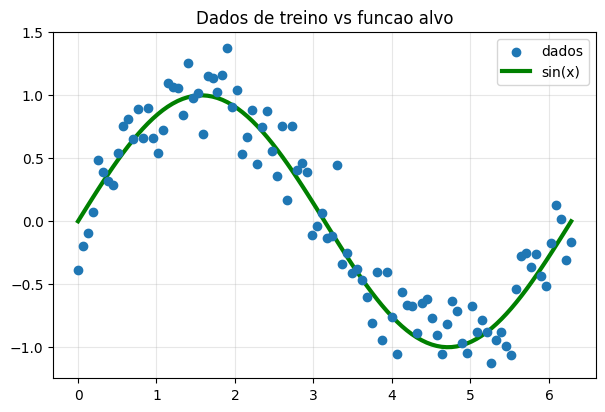

In [3]:
dt = load_data("data/Seno.xlsx")
x = dt["x"].to_numpy(dtype=float)
y_flat = dt["y"].to_numpy(dtype=float)

X = build_design_matrix(x)
y = y_flat.reshape(-1, 1)

plt.scatter(x, y_flat, color="tab:blue", label="dados", zorder=3)
plt.plot(np.sort(x), np.sin(np.sort(x)), color="green", lw=3, label="sin(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Dados de treino vs funcao alvo")
plt.show()


## Treinamento

### Escolha dos hiperparametros

- **`n_hidden = 6`**: numero de neuronios na camada escondida usado no script
  original. Poucos neuronios (2-3) nao capturam a curvatura do seno; muitos
  (>15) aumentam o risco de overfitting em apenas 100 pontos.
- **`learning_rate = 0.01`**: com os inputs em escala pequena e ativacao
  tanh (saturante), essa taxa converge de forma estavel sem oscilar.
- **`n_steps = 100.000`**: gradient descent puro (sem momentum/Adam) precisa
  de muitas iteracoes para convergir totalmente; o grafico de convergencia
  abaixo mostra o SSE estabilizando bem antes do limite.


In [4]:
result = train_mlp(X, y, n_hidden=6, learning_rate=0.01, n_steps=100_000, seed=42)
print(f"SSE final: {result.loss_history[-1]:.4f}")


SSE final: 3.9999


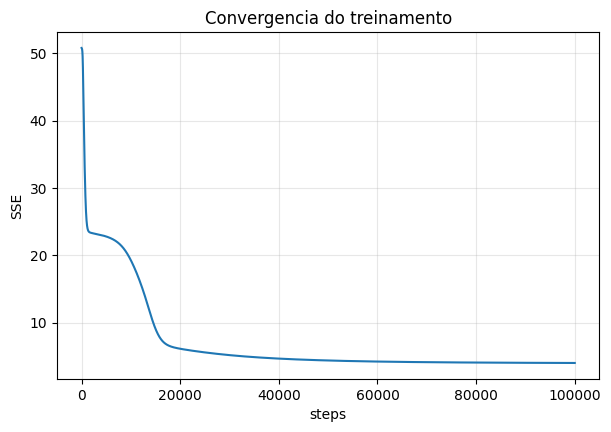

In [5]:
plt.plot(result.loss_history, color="tab:blue")
plt.xlabel("steps")
plt.ylabel("SSE")
plt.title("Convergencia do treinamento")
plt.grid(alpha=0.3)
plt.show()


## Resultado do ajuste

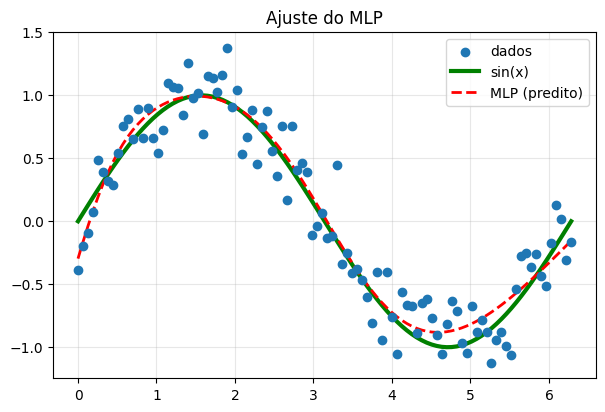

In [6]:
order = np.argsort(x)
_, y_hat = forward(X, result.weights)

plt.scatter(x, y_flat, color="tab:blue", label="dados", zorder=3)
plt.plot(x[order], np.sin(x[order]), color="green", lw=3, label="sin(x)")
plt.plot(x[order], y_hat[order], color="red", lw=2, ls="--", label="MLP (predito)")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Ajuste do MLP")
plt.show()


## Interpretacao das metricas

RMSE e R² medem o quao proxima a saida da rede fica dos dados observados
(nao da funcao alvo sem ruido, que nao esta disponivel em um problema real).
Um R² proximo de 1 e RMSE baixo (proximo do desvio-padrao do ruido injetado)
indicam que o MLP capturou a forma senoidal sem memorizar ruido excessivo.


In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


print(f"RMSE: {rmse(y_flat, y_hat.flatten()):.5f}")
print(f"R2  : {r_squared(y_flat, y_hat.flatten()):.5f}")


RMSE: 0.20000
R2  : 0.92128


## Conclusao

O MLP com backpropagation manual reproduz o comportamento nao-linear do
seno a partir de uma unica camada escondida com ativacao tanh. O proximo
notebook (`03-MLP-Neuralnet-Sklearn/`) resolve o mesmo problema usando uma
biblioteca (`scikit-learn`), equivalente ao pacote `neuralnet` do R,
eliminando a necessidade de derivar o backpropagation manualmente.
